In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("../data/disease10k.csv")

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["has_disease"].value_counts())
print("\nClass percentages:")
print(df["has_disease"].value_counts(normalize=True))

# =========================
# 3. DEFINE FEATURES AND TARGET
# =========================
X = df.drop("has_disease", axis=1)
y = df["has_disease"]

# =========================
# 4. TRAIN / VALIDATION / TEST SPLIT
#    First split into train and temp
#    Then split temp into validation and test
#    Stratify to preserve original class distribution
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

# =========================
# 5. IDENTIFY NUMERIC AND CATEGORICAL COLUMNS
# =========================
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# =========================
# 6. PREPROCESSING
#    - Numeric: impute + scale
#    - Categorical: impute + one-hot encode
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# =========================
# 7. MODEL PIPELINE
#    class_weight='balanced' penalizes mistakes on minority class more
# =========================
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        solver="liblinear",
        random_state=42
    ))
])

# =========================
# 8. HYPERPARAMETER TUNING
#    scoring='recall' because recall is the priority
# =========================
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__penalty": ["l1", "l2"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest params:", grid.best_params_)
print("Best CV recall:", grid.best_score_)

best_model = grid.best_estimator_

# =========================
# 9. VALIDATION PROBABILITIES
#    We will tune threshold here instead of using default 0.5
# =========================
val_probs = best_model.predict_proba(X_val)[:, 1]

# =========================
# 10. THRESHOLD SEARCH
#     Choose threshold based on best recall/F1 tradeoff
#     You can force very high recall if you want
# =========================
thresholds = np.arange(0.05, 0.95, 0.01)

results = []

for threshold in thresholds:
    val_pred = (val_probs >= threshold).astype(int)

    recall = recall_score(y_val, val_pred, zero_division=0)
    precision = precision_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)

    results.append({
        "threshold": threshold,
        "recall": recall,
        "precision": precision,
        "f1": f1
    })

threshold_df = pd.DataFrame(results)

print("\nThreshold tuning results (top 10 by recall then F1):")
print(
    threshold_df.sort_values(
        by=["recall", "f1", "precision"],
        ascending=[False, False, False]
    ).head(10)
)

# =========================
# 11. EXAMPLE THRESHOLD SELECTION RULE
#     Choose among thresholds with recall >= 0.90
#     Then keep the one with highest F1
# =========================
candidate_thresholds = threshold_df[threshold_df["recall"] >= 0.90]

if len(candidate_thresholds) > 0:
    best_row = candidate_thresholds.sort_values(
        by=["f1", "precision"],
        ascending=[False, False]
    ).iloc[0]
else:
    # fallback: pick overall best F1 if no threshold reaches 0.90 recall
    best_row = threshold_df.sort_values(
        by=["f1", "recall"],
        ascending=[False, False]
    ).iloc[0]

best_threshold = best_row["threshold"]

print("\nBEST THRESHOLD:")
print(best_row)


Dataset shape: (10000, 7)

Class distribution:
has_disease
0    9851
1     149
Name: count, dtype: int64

Class percentages:
has_disease
0    0.9851
1    0.0149
Name: proportion, dtype: float64

Shapes:
X_train: (7000, 6)
X_val  : (1500, 6)
X_test : (1500, 6)

Train class distribution:
has_disease
0    0.985143
1    0.014857
Name: proportion, dtype: float64

Validation class distribution:
has_disease
0    0.984667
1    0.015333
Name: proportion, dtype: float64

Test class distribution:
has_disease
0    0.985333
1    0.014667
Name: proportion, dtype: float64

Numeric columns: ['age', 'bmi', 'blood_pressure', 'glucose_level', 'family_history']
Categorical columns: ['physical_activity_level']
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params: {'model__C': 0.01, 'model__penalty': 'l1'}
Best CV recall: 0.8366666666666667

Threshold tuning results (top 10 by recall then F1):
    threshold  recall  precision        f1
17       0.22     1.0   0.030790  0.059740
16      

In [2]:

# =========================
# 12. FINAL VALIDATION METRICS
# =========================
val_pred_final = (val_probs >= best_threshold).astype(int)

val_cm = confusion_matrix(y_val, val_pred_final)
val_recall = recall_score(y_val, val_pred_final, zero_division=0)
val_precision = precision_score(y_val, val_pred_final, zero_division=0)
val_f1 = f1_score(y_val, val_pred_final, zero_division=0)
val_roc_auc = roc_auc_score(y_val, val_probs)
val_pr_auc = average_precision_score(y_val, val_probs)

print("\nVALIDATION CONFUSION MATRIX:")
print(val_cm)

print("\nFINAL VALIDATION METRICS:")
print("Recall:", val_recall)
print("Precision:", val_precision)
print("F1:", val_f1)
print("ROC-AUC:", val_roc_auc)
print("PR-AUC:", val_pr_auc)

print("\nValidation classification report:")
print(classification_report(y_val, val_pred_final, zero_division=0))



VALIDATION CONFUSION MATRIX:
[[927 550]
 [  2  21]]

FINAL VALIDATION METRICS:
Recall: 0.9130434782608695
Precision: 0.03677758318739054
F1: 0.0707070707070707
ROC-AUC: 0.8956168496658914
PR-AUC: 0.24679919662211472

Validation classification report:
              precision    recall  f1-score   support

           0       1.00      0.63      0.77      1477
           1       0.04      0.91      0.07        23

    accuracy                           0.63      1500
   macro avg       0.52      0.77      0.42      1500
weighted avg       0.98      0.63      0.76      1500



In [3]:

# =========================
# 13. FINAL TEST EVALUATION
#     Use the threshold chosen on validation set
# =========================
test_probs = best_model.predict_proba(X_test)[:, 1]
test_pred_final = (test_probs >= best_threshold).astype(int)

test_cm = confusion_matrix(y_test, test_pred_final)
test_recall = recall_score(y_test, test_pred_final, zero_division=0)
test_precision = precision_score(y_test, test_pred_final, zero_division=0)
test_f1 = f1_score(y_test, test_pred_final, zero_division=0)
test_roc_auc = roc_auc_score(y_test, test_probs)
test_pr_auc = average_precision_score(y_test, test_probs)

print("\nTEST CONFUSION MATRIX:")
print(test_cm)

print("\nFINAL TEST METRICS:")
print("Recall:", test_recall)
print("Precision:", test_precision)
print("F1:", test_f1)
print("ROC-AUC:", test_roc_auc)
print("PR-AUC:", test_pr_auc)

print("\nTest classification report:")
print(classification_report(y_test, test_pred_final, zero_division=0))


TEST CONFUSION MATRIX:
[[929 549]
 [  2  20]]

FINAL TEST METRICS:
Recall: 0.9090909090909091
Precision: 0.0351493848857645
F1: 0.0676818950930626
ROC-AUC: 0.8946979948333128
PR-AUC: 0.2202077029048333

Test classification report:
              precision    recall  f1-score   support

           0       1.00      0.63      0.77      1478
           1       0.04      0.91      0.07        22

    accuracy                           0.63      1500
   macro avg       0.52      0.77      0.42      1500
weighted avg       0.98      0.63      0.76      1500



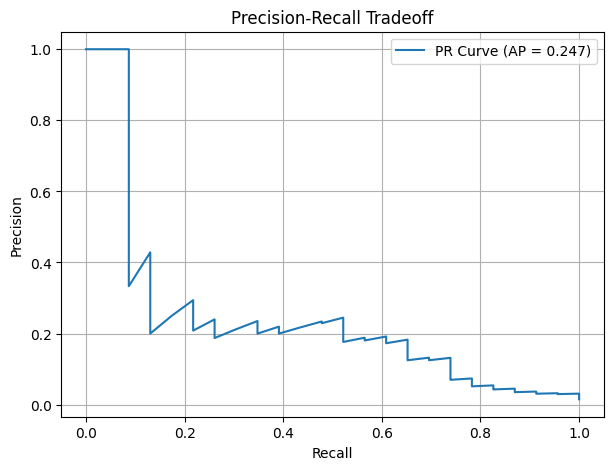

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
pr_auc = average_precision_score(y_val, val_probs)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR Curve (AP = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Tradeoff")
plt.legend()
plt.grid(True)
plt.show()

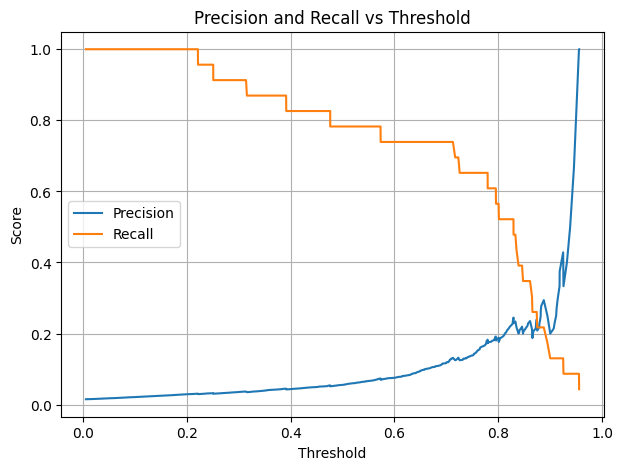

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()